In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Hyperparameters
batch_size = 64
learning_rate = 0.001
num_epochs = 25


In [2]:
# Load FashionMNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


100%|██████████| 26421880/26421880 [00:00<00:00, 97032751.84it/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 7546167.79it/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:00<00:00, 37518640.55it/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 29139375.16it/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



In [3]:
# Autoencoder with nearest Upsampling
class Autoencoder_nearest(nn.Module):
    def __init__(self):
        super(Autoencoder_nearest, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 14*14),
            nn.ReLU()
        )
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest', align_corners=False if 'nearest' != 'nearest' else None)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        x = x.view(x.size(0), 1, 14, 14)
        x = self.upsample(x)
        return x


In [4]:
# Autoencoder with bilinear Upsampling
class Autoencoder_bilinear(nn.Module):
    def __init__(self):
        super(Autoencoder_bilinear, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 14*14),
            nn.ReLU()
        )
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False if 'bilinear' != 'nearest' else None)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        x = x.view(x.size(0), 1, 14, 14)
        x = self.upsample(x)
        return x


In [5]:
# Autoencoder with bicubic Upsampling
class Autoencoder_bicubic(nn.Module):
    def __init__(self):
        super(Autoencoder_bicubic, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 14*14),
            nn.ReLU()
        )
        self.upsample = nn.Upsample(scale_factor=2, mode='bicubic', align_corners=False if 'bicubic' != 'nearest' else None)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        x = x.view(x.size(0), 1, 14, 14)
        x = self.upsample(x)
        return x


In [ ]:
def train_autoencoder(model_class, label, save_path):
    model = model_class()
    model = model.cuda() if torch.cuda.is_available() else model
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0
        
        for data in train_loader:
            img, _ = data
            img = img.cuda() if torch.cuda.is_available() else img
            
            img_flat = img.view(img.size(0), -1)
            
            output = model(img_flat)
            output_flat = output.view(img.size(0), -1)
            
            loss = criterion(output_flat, img.view(img.size(0), -1))
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        
        print(f'{label} Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

    torch.save(model.state_dict(), save_path)
    print(f"Saved trained model to {save_path}")

    return losses


Nearest Epoch [1/25], Loss: 0.0498
Nearest Epoch [2/25], Loss: 0.0332
Nearest Epoch [3/25], Loss: 0.0303
Nearest Epoch [4/25], Loss: 0.0295
Nearest Epoch [5/25], Loss: 0.0282
Nearest Epoch [6/25], Loss: 0.0274
Nearest Epoch [7/25], Loss: 0.0270
Nearest Epoch [8/25], Loss: 0.0268
Nearest Epoch [9/25], Loss: 0.0267
Nearest Epoch [10/25], Loss: 0.0265
Nearest Epoch [11/25], Loss: 0.0262
Nearest Epoch [12/25], Loss: 0.0259
Nearest Epoch [13/25], Loss: 0.0259
Nearest Epoch [14/25], Loss: 0.0258
Nearest Epoch [15/25], Loss: 0.0257
Nearest Epoch [16/25], Loss: 0.0256
Nearest Epoch [17/25], Loss: 0.0256
Nearest Epoch [18/25], Loss: 0.0255
Nearest Epoch [19/25], Loss: 0.0255
Nearest Epoch [20/25], Loss: 0.0254
Nearest Epoch [21/25], Loss: 0.0254
Nearest Epoch [22/25], Loss: 0.0254
Nearest Epoch [23/25], Loss: 0.0253
Nearest Epoch [24/25], Loss: 0.0253
Nearest Epoch [25/25], Loss: 0.0253
Saved trained model to nearest_trained.pth
Bilinear Epoch [1/25], Loss: 0.0456
Bilinear Epoch [2/25], Loss: 0

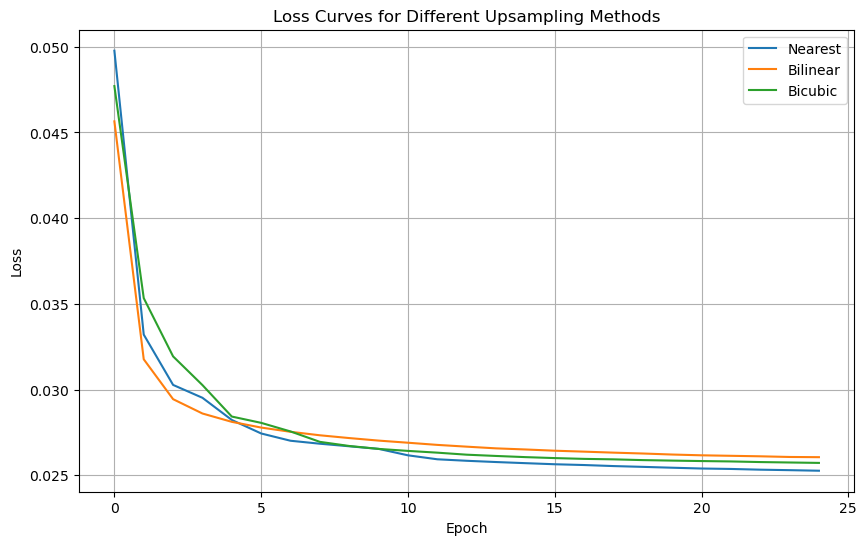

In [7]:
loss_nearest = train_autoencoder(Autoencoder_nearest, "Nearest", "nearest_trained.pth")
loss_bilinear = train_autoencoder(Autoencoder_bilinear, "Bilinear", "bilinear_trained.pth")
loss_bicubic = train_autoencoder(Autoencoder_bicubic, "Bicubic", "bicubic_trained.pth")

# Plot loss curves
plt.figure(figsize=(10, 6))
plt.plot(loss_nearest, label='Nearest')
plt.plot(loss_bilinear, label='Bilinear')
plt.plot(loss_bicubic, label='Bicubic')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves for Different Upsampling Methods')
plt.legend()
plt.grid(True)
plt.show()


In [9]:
# Load FashionMNIST test dataset
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)
test_image, _ = next(iter(test_loader))
test_image_flat = test_image.view(1, -1)
test_image = test_image.cuda() if torch.cuda.is_available() else test_image
test_image_flat = test_image_flat.cuda() if torch.cuda.is_available() else test_image_flat


In [10]:
def load_model(model_class, path):
    model = model_class()
    model.load_state_dict(torch.load(path, map_location='cuda' if torch.cuda.is_available() else 'cpu'))
    model = model.cuda() if torch.cuda.is_available() else model
    model.eval()
    return model


In [11]:
model_nearest = load_model(Autoencoder_nearest, 'nearest_trained.pth')
model_bilinear = load_model(Autoencoder_bilinear, 'bilinear_trained.pth')
model_bicubic = load_model(Autoencoder_bicubic, 'bicubic_trained.pth')


/tmp/ipykernel_222683/3276815777.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location='cuda' if torch.cuda.is_available() 

In [12]:
def fft_image(img_tensor):
    img_np = img_tensor.squeeze().cpu().detach().numpy()
    f = torch.fft.fft2(torch.tensor(img_np))
    fshift = torch.fft.fftshift(f)
    magnitude_spectrum = torch.log(torch.abs(fshift) + 1e-7)
    return magnitude_spectrum

with torch.no_grad():
    recon_nearest = model_nearest(test_image_flat).cpu()
    recon_bilinear = model_bilinear(test_image_flat).cpu()
    recon_bicubic = model_bicubic(test_image_flat).cpu()

# Reshape outputs to 1x28x28
recon_nearest = recon_nearest.view(1, 1, 28, 28)
recon_bilinear = recon_bilinear.view(1, 1, 28, 28)
recon_bicubic = recon_bicubic.view(1, 1, 28, 28)


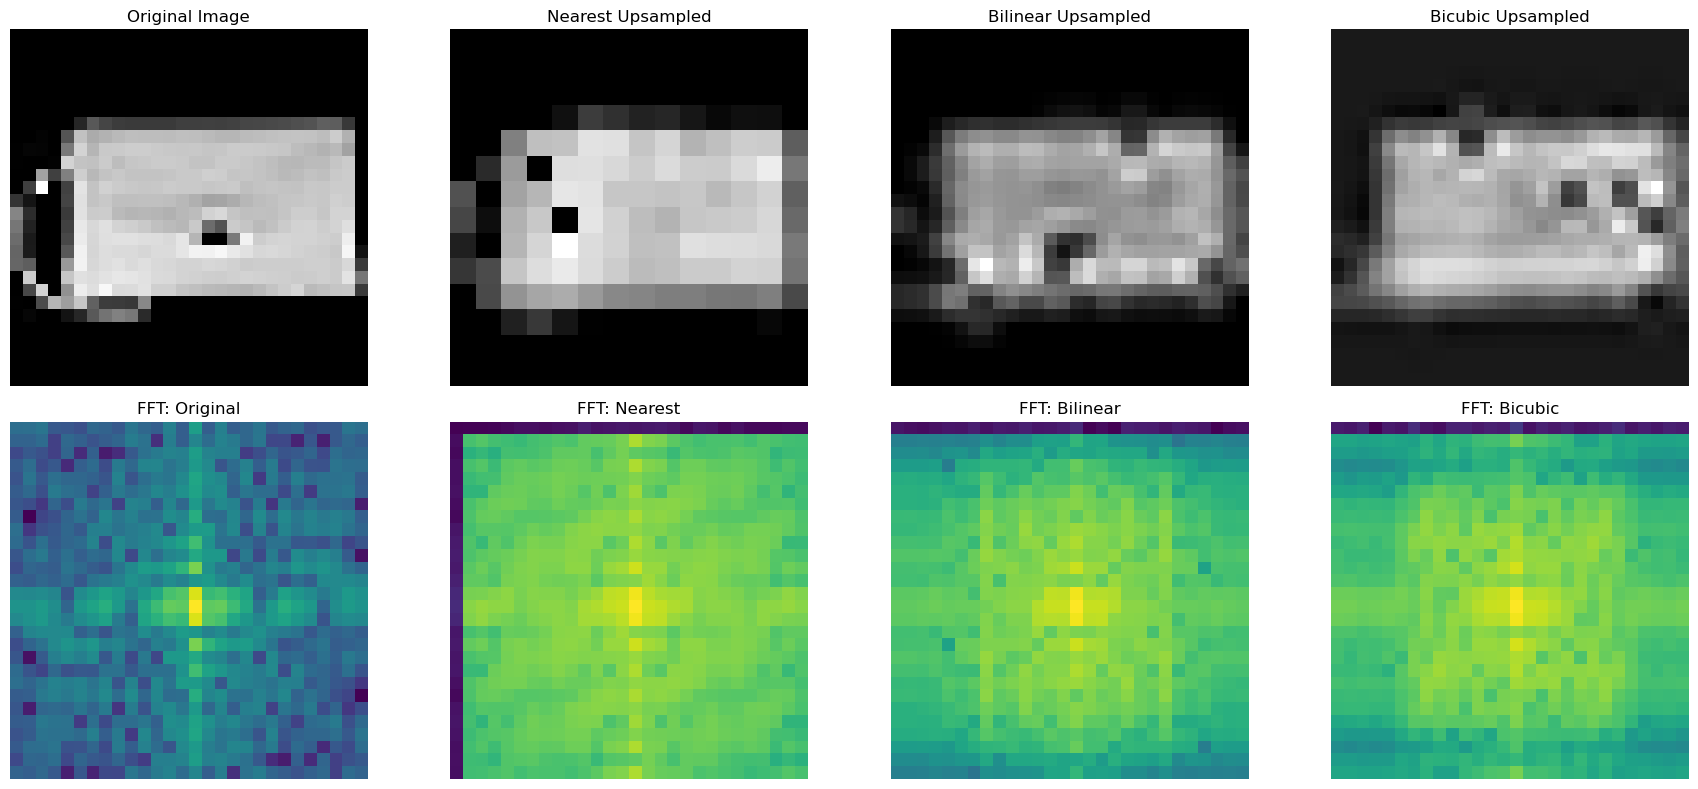

In [13]:
# Plot FFTs
fig, axs = plt.subplots(2, 4, figsize=(18, 8))

# Original image
axs[0, 0].imshow(test_image.squeeze().cpu(), cmap='gray')
axs[0, 0].set_title('Original Image')

# Reconstructions
axs[0, 1].imshow(recon_nearest.squeeze(), cmap='gray')
axs[0, 1].set_title('Nearest Upsampled')

axs[0, 2].imshow(recon_bilinear.squeeze(), cmap='gray')
axs[0, 2].set_title('Bilinear Upsampled')

axs[0, 3].imshow(recon_bicubic.squeeze(), cmap='gray')
axs[0, 3].set_title('Bicubic Upsampled')

# FFTs
axs[1, 0].imshow(fft_image(test_image).numpy(), cmap='viridis')
axs[1, 0].set_title('FFT: Original')

axs[1, 1].imshow(fft_image(recon_nearest).numpy(), cmap='viridis')
axs[1, 1].set_title('FFT: Nearest')

axs[1, 2].imshow(fft_image(recon_bilinear).numpy(), cmap='viridis')
axs[1, 2].set_title('FFT: Bilinear')

axs[1, 3].imshow(fft_image(recon_bicubic).numpy(), cmap='viridis')
axs[1, 3].set_title('FFT: Bicubic')

for ax in axs.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()
